# Avance 3. Baseline

DOMÉNICO MORALES ORTIZ 		A00820324

MÓNICA DODERO ARROYO		    A01795330

OSCAR ANTONIO SUÁREZ V 	    A01323987

INSTITUTO TECNOLÓGICO Y DE ESTUDIOS SUPERIORES DE MONTERREY
TC5035 - Proyecto Integrador

Dra. Grettel Barceló Alonso

Dr. Luis Eduardo Falcón Morales

Mtra. Verónica Sandra Guzmán de Valle

## Instalación de módulos y referencias de librerías

In [ ]:
%pip install astropy
%pip install kaggle
%pip install ultralytics
%pip install opencv-python
%pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 738.7/738.7 kB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 772.7/772.7 kB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 MB 116.3 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import json
import torch
import shutil
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict
from torchvision import transforms
from astropy.io import fits
from torch.utils.data import Dataset, DataLoader
from ultralytics import YOLO
from skimage.feature import canny
from skimage.filters import unsharp_mask
from sklearn.metrics import classification_report, confusion_matrix
from astropy.visualization import ZScaleInterval, LogStretch, MinMaxInterval, LinearStretch
from astropy.visualization import make_lupton_rgb
from sklearn.decomposition import PCA

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
### Colab
from google.colab import drive

#Se necesita montar el drive y acceder a la carpeta donde están los archivos
drive.mount('/content/drive')

# # Cargar el archivo kaggle.json
with open('/content/drive/MyDrive/kaggle.json') as f:
    kaggle_token = json.load(f)

# Configurar las variables de entorno
os.environ['KAGGLE_USERNAME'] = kaggle_token['username']
os.environ['KAGGLE_KEY'] = kaggle_token['key']

# Cargar variables de entorno en colab
#os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
#os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Descargar los datos
path = kagglehub.dataset_download("domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack")

print("Path to dataset files:", path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


100%|██████████| 402M/402M [00:10<00:00, 39.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack/versions/1


In [ ]:
# Direcciones a partir de la descarga
DOWNLOAD_PATH = Path(path) / "ls_dr10_224_gri_262_rgi_stack"
DATA_PATH = DOWNLOAD_PATH / "data"
CSV_PATH = DOWNLOAD_PATH / "lsdr10_paths.csv"

print("DATA path:", DATA_PATH)
print("CSV path:", CSV_PATH)

DATA path: /root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack/versions/1/ls_dr10_224_gri_262_rgi_stack/data
CSV path: /root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack/versions/1/ls_dr10_224_gri_262_rgi_stack/lsdr10_paths.csv


## Funciones de apoyo
Este bloque se encarga de construir las funciones recurrentes en el código.

In [ ]:
# Leer el csv para obtener los tipos de anillo
df = pd.read_csv(CSV_PATH)

# Crear la variable para almacenar tipos de anillo
RING_TYPE = list(df["ring_type"].unique())

def create_dataset_folders(base_path, categories):
  """Crear las carpetas para el dataset de clasificación.

  Args:
      base_path (str): Ruta base del dataset.
      categories (list): Lista de categorías.
  """
  base_path = Path(base_path)
  os.makedirs(base_path, exist_ok=True)
  # Por cada categoría
  for category in categories:
      train_path = base_path / "train" / category
      val_path = base_path / "val" / category
      os.makedirs(train_path, exist_ok=True)
      os.makedirs(val_path, exist_ok=True)
  print(f"Carpetas del dataset creadas en: {base_path}")


def split_dataset(source_dir, base_path, categories, train_ratio=0.8, seed=None):
  """Dividir el dataset en entrenamiento y validación.

  Args:
      source_dir (str): Ruta del dataset original.
      base_path (str): Ruta base del dataset.
      categories (list): Lista de categorías.
      train_ratio (float, optional): Proporción de datos para entrenamiento.
      seed (int, optional): Semilla para la división del dataset.
  """
  np.random.seed(seed)  # Controlar la aleatoriedad
  source_dir = Path(source_dir)
  base_path = Path(base_path)

  dataset_sizes = {"previous": {}, "train": {}, "val": {}}

  # Por cada categoría
  for category in categories:
      category_files = list(source_dir.glob(f"{category}/*.png"))
      dataset_sizes["previous"][category] = len(category_files)
      np.random.shuffle(category_files) # Mezclar los datos

      # Obtener conjunto de entrenamiento
      train_size = int(len(category_files) * train_ratio)
      train_files = category_files[:train_size]
      dataset_sizes["train"][category] = len(train_files)
      # Obtener conjunto de validación
      val_files = category_files[train_size:]
      dataset_sizes["val"][category] = len(val_files)

      # Copiar las imagenes en el dataset a usar
      for file in train_files:
          dest = base_path / "train" / category / file.name
          shutil.copy(file, dest)

      for file in val_files:
          dest = base_path / "val" / category / file.name
          shutil.copy(file, dest)

  print("Dataset anterior:")
  print(dataset_sizes["previous"])
  print("Dataset train:")
  print(dataset_sizes["train"])
  print("Dataset val:")
  print(dataset_sizes["val"])

def subsample_to_max(base_path, categories, max_count=1000, seed=None):
  """Hacer una reducción de datos a las clases según el máximo indicado.

  Args:
      base_path (str): Ruta base del dataset.
      categories (list): Lista de categorías.
      max_count (int, optional): Máximo número de imágenes por clase.
      seed (int, optional): Semilla para la aleatoriedad.
  """
  np.random.seed(seed)  # Controlar la aleatoriedad
  base_path = Path(base_path)

  dataset_sizes = {"train": {}, "val": {}}

  # Por cada categoría
  for category in categories:
      train_path = base_path / "train" / category
      val_path = base_path / "val" / category

      train_files = list(train_path.glob("*.png"))
      val_files = list(val_path.glob("*.png"))

      # Si los datos de entrenamiento sobrepasan el máximo
      if len(train_files) > max_count:
          # Eliminar el excedente
          files_to_remove = np.random.choice(train_files, len(train_files) - max_count, replace=False)
          for file in files_to_remove:
              os.remove(file)

      dataset_sizes["train"][category] = len(list(train_path.glob("*.png")))

      # Si los datos de validación sobrepasan el máximo
      if len(val_files) > max_count:
          # Eliminar el excedente
          files_to_remove = np.random.choice(val_files, len(val_files) - max_count, replace=False)
          for file in files_to_remove:
              os.remove(file)

      dataset_sizes["val"][category] = len(list(val_path.glob("*.png")))

  print("Dataset train:")
  print(dataset_sizes["train"])
  print("Dataset val:")
  print(dataset_sizes["val"])

class AugmentedDataset(Dataset):
  """Dataset personalizado para el aumento de datos empatando a la clase mayoritaria."""
  def __init__(self, root_dir, categories, transform=None, target_count=None, seed=42):
      np.random.seed(seed)
      self.root_dir = Path(root_dir)  # Ruta de los datos
      self.transform = transform      # Conjunto de transformaciones a aplicar
      self.samples = []               # Todas las imágenes
      self.labels = []                # Todas las etiquetas
      self.class_to_idx = {cat: i for i, cat in enumerate(categories)}
      self.idx_to_class = {i: cat for cat, i in self.class_to_idx.items()}

      # Dict {categoría: [lista de rutas de imágenes]}
      class_files = {cat: list(f for f in self.root_dir.glob(f"{cat}/*.png"))
                      for cat in categories}

      # Si no hay máximo especificado, se toma la categoría mayoritaria
      if target_count is None:
          target_count = max(len(files) for files in class_files.values())

      # Por cada imagen de cada categoría
      for cat, files in class_files.items():
          current_count = len(files)
          # Si el número de imágenes no es igual al número máximo
          if current_count < target_count:
              # Obtener un conjunto de imágenes para repetir para alcanzar
              augmentations_needed = target_count - current_count
              augmented_files = np.random.choice(files, augmentations_needed, replace=True)
              files.extend(augmented_files)
          # Si es mayor, elegir un conjunto del número máximo
          elif current_count > target_count:
              files = np.random.choice(files, target_count, replace=False).tolist()

          # Acumular datos y etiquetas
          self.samples.extend(files)
          self.labels.extend([self.class_to_idx[cat]] * len(files))

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
    """Función para obtener un elemento del dataset."""
    img_path = self.samples[idx]
    image = Image.open(img_path).convert('RGB') # Ensure image is in RGB
    label = self.labels[idx]

    if self.transform:
        image = self.transform(image)

    return image, label

  def __str__(self):
    """Función para imprimir información del dataset."""
    class_counts = defaultdict(int)
    for label in self.labels:
        class_counts[self.idx_to_class[label]] += 1
    return f"AugmentedDataset with {len(self)} samples\n" + \
            "\n".join([f"{cls}: {count}" for cls, count in class_counts.items()])

def visualize_augmented_images(dataloader):
  """Visualizar imágenes aumentadas."""
  dataiter = iter(dataloader)
  images, labels = next(dataiter)

  plt.subplots(4, 5, figsize=(20, 10))
  for i in range(20):
      plt.subplot(4, 5, i + 1)
      title = RING_TYPE[labels[i]]
      img = images[i].numpy().transpose((1, 2, 0))  # Convertir de Tensor a numpy
      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      img = std * img + mean  # Regresar de la normalización
      img = np.clip(img, 0, 1)  # Clip
      plt.imshow(img)
      plt.title(title + str(i))
      plt.axis('off')
  plt.suptitle('Ejemplo de imagenes aumentadas')
  plt.tight_layout()
  plt.show()

## Arquitectura de datos

Para aplicaciones como clasificación debemos tener cierta arquitectura...

Dividir entre train y val...

```
ls_dr10_224_gri_262_rgi_stack-/
|
|-- train/
|   |-- inner/
|   |   |-- SDSS_1237648720693756035_inner_ra179.803680_dec-0.523807_s224.png
|   |   |-- SDSS_1237648721216798768_inner_ra148.183030_dec-0.058260_s224.png
|   |   |-- ...
|   |
|   |-- inner+outer/
|   |   |-- SDSS_1237648720159309954_inner+outer_ra185.303930_dec-0.864249_s224.png
|   |   |-- SDSS_1237648722827346065_inner+outer_ra148.047750_dec1.095468_s224.png
|   |   |-- ...
|   |
|   |-- none/
|   |   |-- SDSS_1237648673994965546_none_ra243.236760_dec-0.096260_s224.png
|   |   |-- SDSS_1237648675606430099_none_ra245.086640_dec1.228430_s224.png
|   |   |-- ...
|   |
|   |-- outer/
|   |   |-- SDSS_1237648672921485632_outer_ra243.708880_dec-0.915654_s224.png
|   |   |-- SDSS_1237648720151773317_outer_ra168.044330_dec-0.979234_s224.png
|   |   |-- ...
|
|-- val/
|   |-- inner/
|   |   |-- SDSS_1237648703509430283_inner_ra197.265150_dec-0.766004_s224.png
|   |   |-- SDSS_1237648703515590916_inner_ra211.355260_dec-0.811356_s224.png
|   |   |-- ...
|   |
|   |-- inner+outer/
|   |   |-- SDSS_1237651067888206006_inner+outer_ra174.683510_dec65.903503_s224.png
|   |   |-- SDSS_1237651714799829110_inner+outer_ra251.458470_dec43.866490_s224.png
|   |   |-- ...
|   |
|   |-- none/
|   |   |-- SDSS_1237648673997127724_none_ra248.064170_dec-0.049930_s224.png
|   |   |-- SDSS_1237648702966988820_none_ra184.535660_dec-1.064119_s224.png
|   |   |-- ...
|   |
|   |-- outer/
|   |   |-- SDSS_1237648704590643362_outer_ra214.342420_dec0.023720_s224.png
|   |   |-- SDSS_1237651251484688595_outer_ra128.182930_dec49.952348_s224.png
|   |   |-- ...
```


In [ ]:
# Crear las carpetas para el dataset
create_dataset_folders("dataset", RING_TYPE)
# Dividir el dataset
split_dataset(DATA_PATH, "dataset", RING_TYPE, seed=42)

Carpetas del dataset creadas en: dataset
Dataset anterior:
{'none': 6646, 'inner': 853, 'inner+outer': 370, 'outer': 186}
Dataset train:
{'none': 5316, 'inner': 682, 'inner+outer': 296, 'outer': 148}
Dataset val:
{'none': 1330, 'inner': 171, 'inner+outer': 74, 'outer': 38}


## Aumento de datos

El problema de las clases no balanceadas en un problema de clasificación no es tan fácil de abordarlo porque precisamente en lo general, no se tiene la información suficiente de una de las clases. Imaginemos el caso donde dejemos a la suerte nuestro conjunto de datos al modelo tal cual, podríamos tener un modelo con una exactitud del 98%, lo cual podría parecer excelente; pero ¿de qué sirve este modelo de 98% de exactitud, si no sabe detectar o clasificar si existe un anillo o no, ya que ese 98% refleja que en todo momento este modelo hace predicciones va a ir siempre para la clase mayoritaria y con ello ya garantiza un 98% de buenas predicciones con los datos de la clase mayoritaria y digamos que acepta a cambio tener un 2% de error con las malas predicciones de la clase positiva. Es por ese motivo, el cual un modelo puede clasificar mejor si las clases están balanceadas para reflejar una clasificar más exacto con base en la realidad de pesos que tiene cada etiqueta de tipo de anillo en nuestro dataset.

En nuestro caso, estamos delimitando el número máximo de imágenes por clase. Así como aplicar aumentar la diversidad de nuestro dataset sin necesidad de recolectar más datos con transformaciones tales como:

- Espejo Horizontal/Vertical
- Rotar por ángulos y rellenar
- Reescalar los valores de píxeles a estadísticas que el modelo YOLOv11 conoce, centrando los valores de cada canal alrededor a 0


Dataset train:
{'none': 1000, 'inner': 682, 'inner+outer': 296, 'outer': 148}
Dataset val:
{'none': 1000, 'inner': 171, 'inner+outer': 74, 'outer': 38}
AugmentedDataset with 4000 samples
none: 1000
inner: 1000
inner+outer: 1000
outer: 1000
AugmentedDataset with 4000 samples
none: 1000
inner: 1000
inner+outer: 1000
outer: 1000


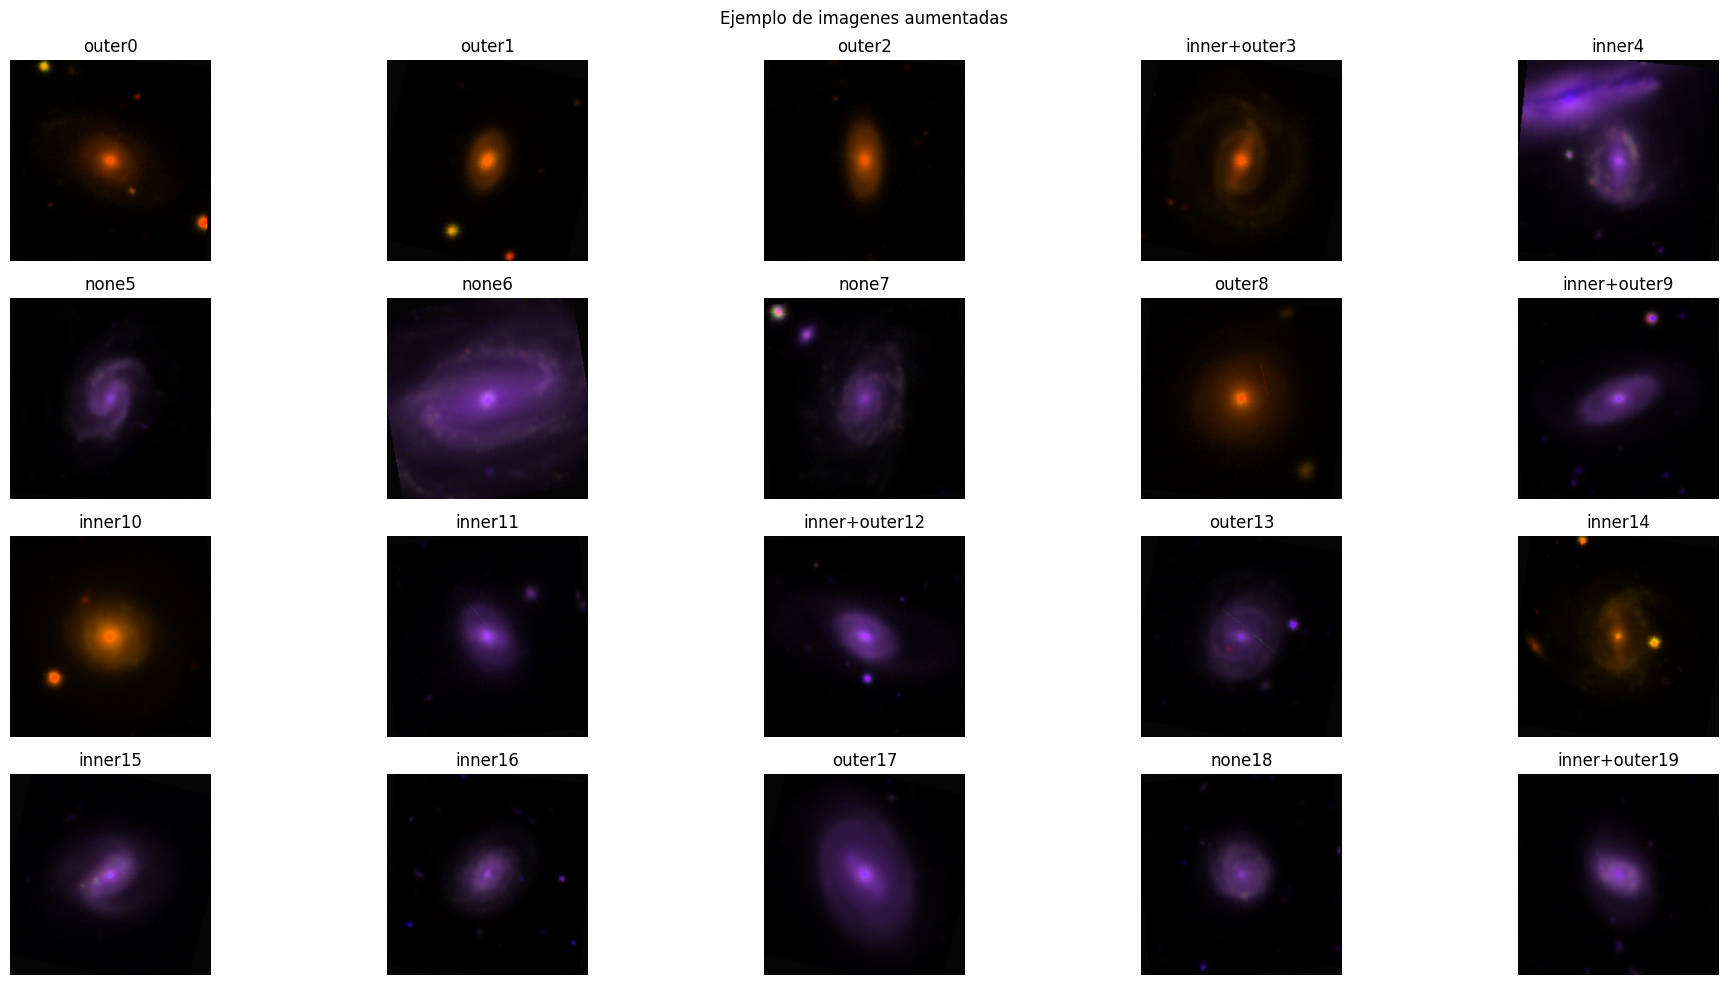

In [ ]:
# Limitar el número máximo de la clase mayoritaria
subsample_to_max("dataset", RING_TYPE, max_count=1000, seed=42)

# Transformaciones para entrenamiento
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),      # Espejo horizontal
    transforms.RandomVerticalFlip(),        # Espejo vertical
    transforms.RandomRotation(15, fill=5),  # Rotar en rango de 15 grados
    transforms.ToTensor(),
    # Normalización acorde al preentrenamiento del modelo
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transfromaciones para validación
val_transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalización acorde al preentrenamiento del modelo
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Crear los datasets aumentados
train_dataset = AugmentedDataset('dataset/train', RING_TYPE, transform=train_transform, target_count=None)
val_dataset = AugmentedDataset('dataset/val', RING_TYPE, transform=val_transform, target_count=None)

# Creatar los Dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(train_dataloader.dataset)
print(val_dataloader.dataset)

# Visualizar ejemplos de imagenes aumentadas
visualize_augmented_images(train_dataloader)

## Construcción del modelo

Se usa como modelo pre-entrenado YOLO11s para clasificación debido a que tiene bloque attention y este además cuenta con la siguiente arquitectura que lo hace atractivo:

- Usa capas convolucionales para transformar la imagen en mapas de características.
- Usa el bloque C2PSA, que aplica atención espacial para enfocarse en regiones importantes.
- Toma los mapas refinados y nos ayuda a generar una clasificación: ¿Qué clase de anillo es?

Referencia: Khanam, R., Hussain, M. YOLOv11: An Overview of the Key Architectural Enhancements https://arxiv.org/html/2410.17725v1

Utilizamos los siguientes parámetros para los siguientes cometidos
- CrossEntropyLoss: función de pérdida para clasificación multiclase.

- Adam: optimizador adaptativo.

- lr=0.0001: tasa de aprendizaje baja para evitar un sobreentrenamiento.

- num_epochs=50: número de ciclos completos de entrenamiento.

Se realiza como un tipo de fine-tunning para habilitar el entrenamiento solo en los últimos dos bloques:

- model[-2]: el bloque de atención espacial (C2PSA), que ayuda a enfocar el modelo en regiones relevantes.

- model[-1]: el head de clasificación, que convierte las características en predicciones de clase

Por qué? El backbone ya fue entrenado en millones de imágenes (ImageNet), y tiene una base predefinida capaz de detectar bordes, texturas, formas.

De igual forma, el _head_ (model.model[-1]) es la parte que traduce las características en predicciones. Es la capa más propensa a sobreajuste, porque está directamente conectada a las etiquetas, por eso se empleo como parte de regularizar justo donde más creemos necesario con un dropout aleatorio de neuronas algo agresivo de 0.7


In [ ]:
# Cargar el modelo pre-entrenado
model = YOLO('yolo11s-cls.pt').model

# Asignar GPU o CPU en su defecto
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Información del modelo
print("Model:")
model.info()
# Información del device a usar
print("Device:", device)

# Parámetros de entrenamiento
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 50

# Modificar el head del modelo
model.model[-1].drop = nn.Dropout(p=0.7)  # Añadir Dropout al 70%
model.model[-1].linear = nn.Linear(model.model[-1].linear.in_features, len(RING_TYPE)) # Ajustar neuronas de salida
print(model.model[-1])

# Descongelar pesos a entrenar
for param in model.model[-2].parameters():  # Pesos asignados al bloque C2PSA (Attention)
    param.requires_grad = True

for param in model.model[-1].parameters():  # Pesos asignados al bloque Classify (Head)
    param.requires_grad = True

# Asegurar los pesos a entrenar
print("\nModel parameters:")
for param in model.named_parameters():
    print(param[0], param[1].requires_grad)

# Pasar el modelo al device
model.to(device)

Model:
YOLO11s-cls summary: 86 layers, 6,724,008 parameters, 0 gradients, 13.2 GFLOPs
Device: cpu
Classify(
  (conv): Conv(
    (conv): Conv2d(512, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (drop): Dropout(p=0.7, inplace=False)
  (linear): Linear(in_features=1280, out_features=4, bias=True)
)

Model parameters:
model.0.conv.weight False
model.0.bn.weight False
model.0.bn.bias False
model.1.conv.weight False
model.1.bn.weight False
model.1.bn.bias False
model.2.cv1.conv.weight False
model.2.cv1.bn.weight False
model.2.cv1.bn.bias False
model.2.cv2.conv.weight False
model.2.cv2.bn.weight False
model.2.cv2.bn.bias False
model.2.m.0.cv1.conv.weight False
model.2.m.0.cv1.bn.weight False
model.2.m.0.cv1.bn.bias False
model.2.m.0.cv2.conv.weight False
model.2.m.0.cv2.bn.weight False
model.2.m.0.cv2.bn.bias False
m

ClassificationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )


## Entrenamiento del modelo

Se crea un loop de entrenamiento donde podemos usar nuestro dataloader, empezando en crear listas vacías para guardar el loss y accuracy de cada epoca, tanto en entrenamiento como en validación y esto nos permite saber el progreso de nuestro modelo y observar algún posible sobreentrenamiento.

Se guarda el modelo si es la primera epoca o si mejora el accuracy de validación.Este flujo es modular y reproducible, ideal para comparar configuraciones para las futuras entregas en donde podemos hacer uso de otras herramientas para avanzar y mejorar con las métricas de desempeño.

In [ ]:
# Entrenar el modelo
# Placeholders para graficar
train_loss = []
train_acc = []
val_loss = []
val_acc = []

# Loop de entrenamiento
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Por cada dato en nuestro batch
    for i, (images, labels) in enumerate(train_dataloader):
        print(f"{i+1}/{len(train_dataloader)}", end='\r')

        # Pasar al device
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()   # Limpiar gradientes

        outputs = model(images) # Forward pass
        loss = criterion(outputs, labels) # Calcular loss
        loss.backward()         # Backpropagation (obtener gradientes)
        optimizer.step()        # Actualizar pesos

        running_loss += loss.item() * images.size(0)  # Obtener loss total
        _, preds = torch.max(outputs, 1)              # Predicciones
        correct += (preds == labels).sum().item()     # Calcular correctas
        total += labels.size(0)                       # Calcular total

    epoch_loss = running_loss / total # Loss por época
    epoch_acc = correct / total       # Accuracy por época
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

    # Validación
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        # Por cada dato en nuestro batch
        for images, labels in val_dataloader:
            # Pasar al device
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # Forward pass
            if isinstance(outputs, tuple):
                outputs = outputs[0]  # Obtener el primer elemento si es tupla
            loss = criterion(outputs, labels) # Calcular loss
            running_loss += loss.item() * images.size(0)  # Obtener loss total
            _, preds = torch.max(outputs, 1)              # Predicciones
            correct += (preds == labels).sum().item()     # Calcular correctas
            total += labels.size(0)                       # Calcular total

    epoch_loss = running_loss / total # Loss por época
    val_accuracy = correct / total    # Accuracy por época
    val_loss.append(epoch_loss)
    val_acc.append(val_accuracy)
    print(f"Validation Loss: {epoch_loss:.4f}, Accuracy: {val_accuracy:.4f}")

    # Guardar los mejores pesos
    if epoch == 0:
        best_val_acc = val_accuracy
        torch.save(model, f'best_model_e{epoch}_acc{val_accuracy*100:.0f}.pt')
    else:
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model, f'best_model_e{epoch}_acc{val_accuracy*100:.0f}.pt')
            print("Model guardado con accuracy:", best_val_acc)

Epoch 1/50, Loss: 1.4754, Accuracy: 0.3272
Validation Loss: 1.3435, Accuracy: 0.3902
Epoch 2/50, Loss: 1.2579, Accuracy: 0.4370
Validation Loss: 1.3176, Accuracy: 0.4407
Model guardado con accuracy: 0.44075
Epoch 3/50, Loss: 1.1786, Accuracy: 0.4775
Validation Loss: 1.3062, Accuracy: 0.4308
Epoch 4/50, Loss: 1.1039, Accuracy: 0.5172
Validation Loss: 1.2951, Accuracy: 0.4575
Model guardado con accuracy: 0.4575
Epoch 5/50, Loss: 1.0460, Accuracy: 0.5485
Validation Loss: 1.2931, Accuracy: 0.4298
Epoch 6/50, Loss: 1.0050, Accuracy: 0.5647
Validation Loss: 1.2865, Accuracy: 0.4632
Model guardado con accuracy: 0.46325
Epoch 7/50, Loss: 0.9561, Accuracy: 0.5938
Validation Loss: 1.2806, Accuracy: 0.4685
Model guardado con accuracy: 0.4685
Epoch 8/50, Loss: 0.9155, Accuracy: 0.6192
Validation Loss: 1.2745, Accuracy: 0.4768
Model guardado con accuracy: 0.47675
Epoch 9/50, Loss: 0.8759, Accuracy: 0.6360
Validation Loss: 1.2781, Accuracy: 0.4698
Epoch 10/50, Loss: 0.8293, Accuracy: 0.6660
Validati

## Evaluación del modelo

Las gráficas indican que el mejor punto para esta sesion de entrenamiento se encuentra en el epoch 11: la perdida de validación toca mínimo y la precisión de validación alcanza su pico; después ambos se degradan mientras la precisión de entrenamiento sube hasta ~0.90. Esto señala sobreentrenamiento a partir de ese punto. Con test balanceado, precisión 0.51 y macro-F1 0.50: por encima del azar de cuatro clases, pero todavía limitado para uso confiable.

La matriz de confusión muestra que “none” y “outer” son las clases más manejables (recalls 0.66 y 0.59). “inner” se diluye con frecuencia hacia “none” y “outer”, lo que sugiere señal interna tenue o poco destacada. “inner+outer” es la más problemática: solo 337 correctas; la mayoría se reparte como “outer” (271) o “inner” (207), es decir, el modelo detecta un anillo pero no la co-ocurrencia. También aparecen falsos positivos desde “none” hacia anillos, probablemente por bordes o texturas circulares. En conjunto, el modelo generaliza mejor para confirmar ausencia o anillos externos y necesita más señal y regularización para separar “inner” y reconocer ambos a la vez.

En otras sesiones de entrenamiento se alcanzo una precisión con el conjunto de validacion de hasta el 80%, pero al ser un modelo no determinista el desempeño puede variar entre corridas por la inicialización de pesos, el orden de los lotes y los aumentos de datos.

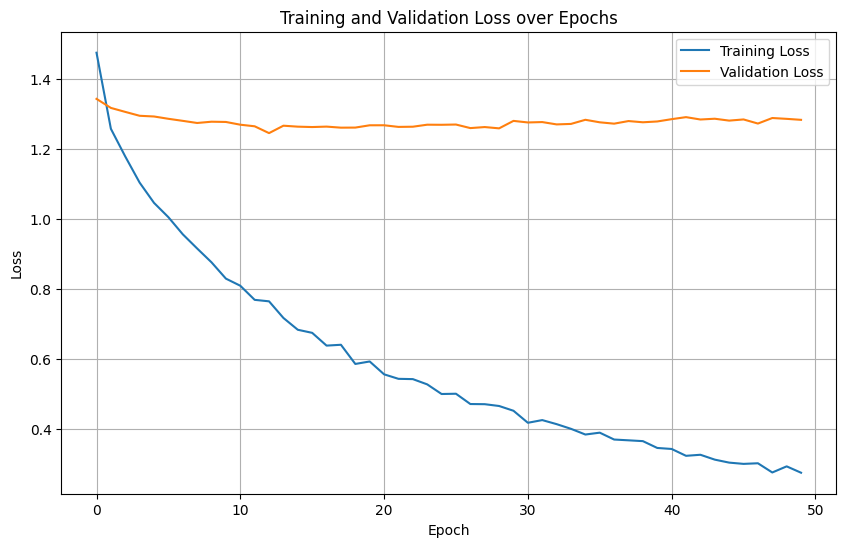

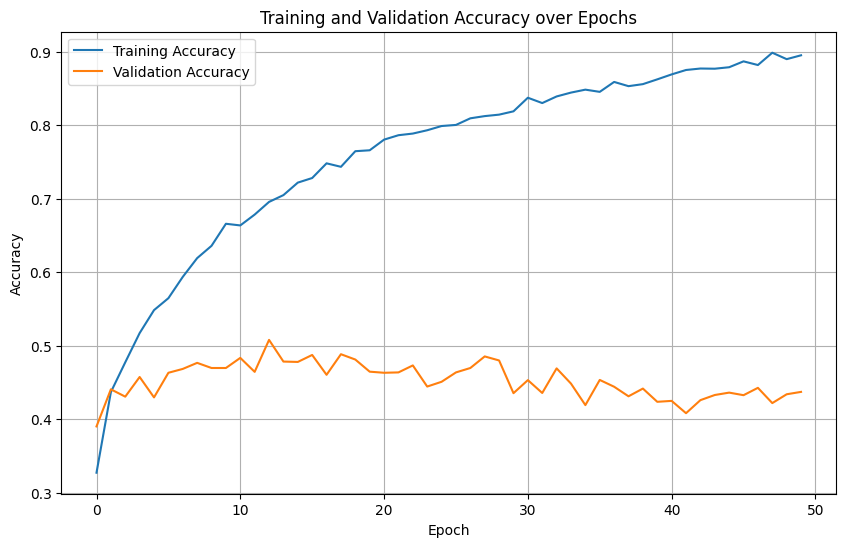

In [ ]:
# Gráfica de loss a través de las épocas
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de accuracy a través de las épocas
plt.figure(figsize=(10, 6))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluar el modelo en el conjunto de validación
model = torch.load('/content/best_model_e12_acc51.pt', weights_only=False)

model.eval()
all_preds = []
all_labels = []

# Loop para obtener predicciones
with torch.no_grad():
    for images, labels in val_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    print(len(all_labels), len(all_preds))


4000 4000


Classification Report:
              precision    recall  f1-score   support

        none       0.60      0.66      0.62      1000
       inner       0.45      0.45      0.45      1000
 inner+outer       0.46      0.34      0.39      1000
       outer       0.50      0.59      0.54      1000

    accuracy                           0.51      4000
   macro avg       0.50      0.51      0.50      4000
weighted avg       0.50      0.51      0.50      4000

Confusion Matrix:


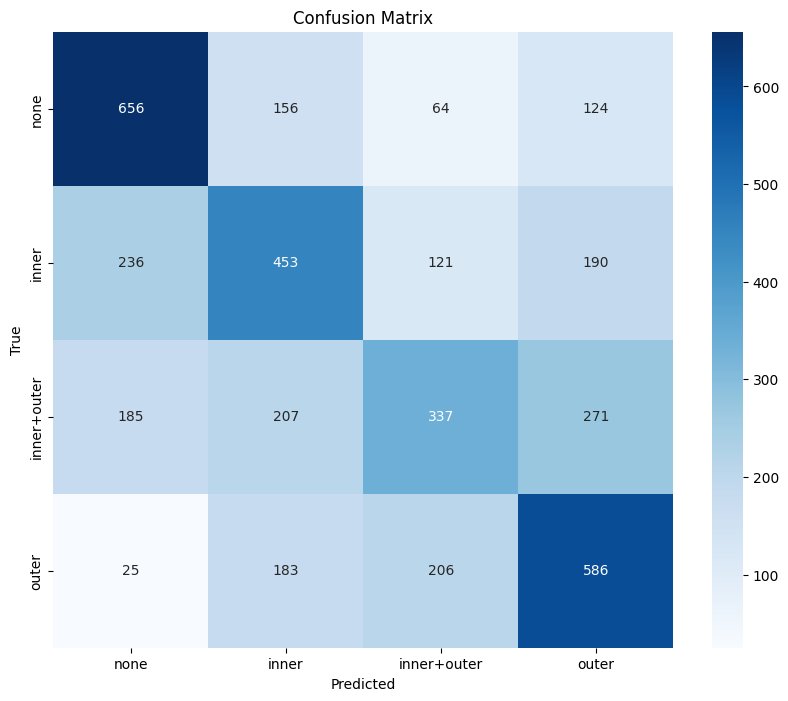

In [ ]:
# Generar el reporte de clasificación
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=RING_TYPE))
# Generar la matriz de confusión
print("Confusion Matrix:")
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=RING_TYPE, yticklabels=RING_TYPE, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

## Conclusiones

Con el flujo seguido hasta ahora, hemos logrado construir una base funcional para detectar patrones de anillos. Las decisiones de preprocesamiento y los aumentos de datos facilitaron el entrenamiento, pero no fueron suficientes para resolver con consistencia la clasificación entre clases parecidas.

Optamos por un clasificador convolucional con pesos preentrenados y una cabeza adaptada al número de clases. Elejimos este modelo porque reconoce patrones aunque cambien de posición y ve detalles a distintas escalas, lo que ayuda a diferenciar entre galaxias anulares.

Partimos de un conjunto de datos fuertemente desbalanceado (predomina “none”). Por esa diferencia, un clasificador que siempre predijera la clase mayoritaria obtendria un 98% de precisión. Para evitar esa ilusión de desempeño, se evaluó con un conjunto de prueba balanceado, donde el piso razonable es 25%. En este contexto, los resultados obtenidos muestran aprendizaje real, pero aún con un margen amplio de mejora.

Nuestro mejor modelo consiguio una precisión del 83% en el conjunto de validación. No encontramos un antecendente sobre la clasificacion de anillos galacticos, solo clasificacion binaria entre galaxias sin o con anillo. Por esta razon tomaremos la precision de nuestro mejor modelo como base para determinar si hemos encontrado una mejora aceptable.

En los siguientes pasos mantendremos la misma arquitectura y entrenaremos el modelo usando técnicas de preprocesamiento y de extracción de características alternativas. Probaremos variantes que fortalezcan la señal de los anillos, junto con normalizaciones robustas y limpieza de fondo y de estrellas, con la intención de aislar qué combinación de preprocesamiento y rasgos reduce la confusión entre las clases e incrementa la precisión del modelo.